# Experiment 1 — Healthy complete Circle of Willis baseline

This notebook validates the complete CoW geometry with six 0D regional capillary beds. The goal is not to fit patient-specific data; it is to check that the model produces physiologically reasonable regional perfusion and capillary pressure in a healthy baseline.

The notebook uses pressure inlets generated by `hemo1d.create_arterial_pressure_inflow(...)` from the source code, so the pressure waveform is not redefined here.

## References used for interpretation

- Normal adult cerebral blood flow is commonly summarized as about 750 mL/min, or about 50–54 mL/100 g/min. Ischemic concern is often discussed below about 18–20 mL/100 g/min, with severe injury at lower values.
- The Circle of Willis is a collateral network: under unilateral carotid stenosis, the anterior communicating artery can provide right-to-left or left-to-right compensation, while posterior communicating arteries may recruit posterior-anterior compensation depending on anatomy.
- In this project, the six 0D terminal beds are not meant to reproduce exact patient-specific tissue territories. They are a controlled physiological calibration that converts 1D outlet flows into regional perfusion metrics.


In [3]:

from __future__ import annotations

import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import hemo1d as hd

# All notebooks are intended to be run from the repository root.
BASE_CONFIG_PATH = Path("./configs/CoW_normal.json")
GENERATED_CONFIG_DIR = Path("./configs/generated_notebooks")
OUTPUT_ROOT = Path("./outputs/notebooks")

MMHG_TO_DYN_CM2 = 1333.22

# Solver settings. Increase T_END / decrease DT for final polished results.
METHOD = "CG"
DG_TIME_SCHEME = "rk2"
DEGREE = 1
H = 0.0625
DT = 1.0e-5
T_END = 2.0
RECORD_EVERY = 10
SHOW_PLOTS = False

HEART_RATE = 1.2    # Hz, about 72 bpm
RAMP_TIME = 0.20    # seconds

# Six tissue territories represented by six 0D capillary beds.
EXPECTED_BEDS = {
    "L-ACA_bed": {"target_flow_ml_min": 100.0, "target_perfusion": 50.0, "target_pcap_mmhg": 35.0},
    "R-ACA_bed": {"target_flow_ml_min": 100.0, "target_perfusion": 50.0, "target_pcap_mmhg": 35.0},
    "L-MCA_bed": {"target_flow_ml_min": 190.0, "target_perfusion": 50.0, "target_pcap_mmhg": 35.0},
    "R-MCA_bed": {"target_flow_ml_min": 190.0, "target_perfusion": 50.0, "target_pcap_mmhg": 35.0},
    "L-PCA_bed": {"target_flow_ml_min": 85.0,  "target_perfusion": 50.0, "target_pcap_mmhg": 35.0},
    "R-PCA_bed": {"target_flow_ml_min": 85.0,  "target_perfusion": 50.0, "target_pcap_mmhg": 35.0},
}

STANDARD_CAPILLARY_BEDS = {
    "L-ACA_bed": {
        "outlets": [{"vessel_id": "L-ACA_II", "side": "right", "R_art": 3.600e4}],
        "C": 6.95e-6, "R_ven": 2.160e4, "P_ven": 1.0666e4,
        "P0": 4.6663e4, "tissue_volume": 200.0,
    },
    "R-ACA_bed": {
        "outlets": [{"vessel_id": "R-ACA_II", "side": "right", "R_art": 3.600e4}],
        "C": 6.95e-6, "R_ven": 2.160e4, "P_ven": 1.0666e4,
        "P0": 4.6663e4, "tissue_volume": 200.0,
    },
    "L-MCA_bed": {
        "outlets": [{"vessel_id": "L-MCA", "side": "right", "R_art": 1.895e4}],
        "C": 1.32e-5, "R_ven": 1.137e4, "P_ven": 1.0666e4,
        "P0": 4.6663e4, "tissue_volume": 380.0,
    },
    "R-MCA_bed": {
        "outlets": [{"vessel_id": "R-MCA", "side": "right", "R_art": 1.895e4}],
        "C": 1.32e-5, "R_ven": 1.137e4, "P_ven": 1.0666e4,
        "P0": 4.6663e4, "tissue_volume": 380.0,
    },
    "L-PCA_bed": {
        "outlets": [{"vessel_id": "L-PCA_II", "side": "right", "R_art": 4.235e4}],
        "C": 5.90e-6, "R_ven": 2.541e4, "P_ven": 1.0666e4,
        "P0": 4.6663e4, "tissue_volume": 170.0,
    },
    "R-PCA_bed": {
        "outlets": [{"vessel_id": "R-PCA_II", "side": "right", "R_art": 4.235e4}],
        "C": 5.90e-6, "R_ven": 2.541e4, "P_ven": 1.0666e4,
        "P0": 4.6663e4, "tissue_volume": 170.0,
    },
}

PROBE_VESSELS = (
    "BAS", "L-ICA_I", "R-ICA_I", "ACA", "L-PCommA", "R-PCommA",
    "L-MCA", "R-MCA", "L-ACA_II", "R-ACA_II", "L-PCA_II", "R-PCA_II",
)


def load_base_config() -> dict:
    if not BASE_CONFIG_PATH.exists():
        raise FileNotFoundError(
            f"Could not find {BASE_CONFIG_PATH}. Run this notebook from the repository root."
        )
    with BASE_CONFIG_PATH.open() as f:
        return json.load(f)


def write_config(config: dict, name: str) -> Path:
    GENERATED_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
    path = GENERATED_CONFIG_DIR / name
    with path.open("w") as f:
        json.dump(config, f, indent=2)
    return path


def prepare_base_cow_config() -> dict:
    """Return a copy of the CoW config with physiological p0 and six capillary beds."""
    config = copy.deepcopy(load_base_config())
    config.setdefault("defaults", {})
    config["defaults"]["p0"] = 80.0 * MMHG_TO_DYN_CM2
    config["defaults"]["p_ext"] = 0.0
    config["capillary_beds"] = copy.deepcopy(STANDARD_CAPILLARY_BEDS)
    return config


def set_pressure_inlets(model) -> None:
    """Use the source-code arterial pressure waveform factory, not a notebook-local one."""
    model.set_inlet(
        vessel_id="L-ICA_I",
        kind="pressure",
        function=hd.create_arterial_pressure_inflow(
            mean_mmhg=85.0,
            amp1_mmhg=14.0,
            amp2_mmhg=4.0,
            heart_rate=HEART_RATE,
            ramp_time=RAMP_TIME,
            phase_s=0.00,
        ),
    )
    model.set_inlet(
        vessel_id="R-ICA_I",
        kind="pressure",
        function=hd.create_arterial_pressure_inflow(
            mean_mmhg=85.0,
            amp1_mmhg=14.0,
            amp2_mmhg=4.0,
            heart_rate=HEART_RATE,
            ramp_time=RAMP_TIME,
            phase_s=0.00,
        ),
    )
    model.set_inlet(
        vessel_id="BAS",
        kind="pressure",
        function=hd.create_arterial_pressure_inflow(
            mean_mmhg=84.0,
            amp1_mmhg=11.0,
            amp2_mmhg=3.0,
            heart_rate=HEART_RATE,
            ramp_time=RAMP_TIME,
            phase_s=0.04,
        ),
    )


def configure_model(config_path: Path):
    model = hd.load_from_config(config_path)
    set_pressure_inlets(model)
    model.set_solver(
        method=METHOD,
        h=H,
        dt=DT,
        poly_order=DEGREE,
        dg_time_scheme=DG_TIME_SCHEME,
        record_every=RECORD_EVERY,
    )
    for vessel_id in PROBE_VESSELS:
        if vessel_id not in model.config.vessels:
            continue
        length = model.config.vessel(vessel_id).length
        model.add_probe(vessel_id=vessel_id, position=0.5 * length, name="mid")
    return model


def late_mask(times: np.ndarray, fraction: float = 0.25) -> np.ndarray:
    tail_start = times[-1] - fraction * (times[-1] - times[0])
    return times >= tail_start


def summarize_beds(results) -> pd.DataFrame:
    rows = []
    for bed_id, expected in EXPECTED_BEDS.items():
        samples = results.capillary_bed_history(bed_id)
        times = np.array([s.time for s in samples])
        tail = late_mask(times)
        pcap_mmhg = np.array([s.pressure for s in samples]) / MMHG_TO_DYN_CM2
        inflow_ml_min = np.array([s.total_inflow for s in samples]) * 60.0
        venous_ml_min = np.array([s.venous_outflow for s in samples]) * 60.0
        perfusion = np.array([s.regional_perfusion for s in samples]) * 6000.0
        rows.append({
            "bed": bed_id,
            "target_pcap_mmhg": expected["target_pcap_mmhg"],
            "pcap_mmhg": float(np.mean(pcap_mmhg[tail])),
            "pcap_min_tail": float(np.min(pcap_mmhg[tail])),
            "pcap_max_tail": float(np.max(pcap_mmhg[tail])),
            "target_flow_ml_min": expected["target_flow_ml_min"],
            "flow_ml_min": float(np.mean(inflow_ml_min[tail])),
            "venous_ml_min": float(np.mean(venous_ml_min[tail])),
            "target_perfusion": expected["target_perfusion"],
            "perfusion": float(np.mean(perfusion[tail])),
        })
    return pd.DataFrame(rows)


def probe_late_mean_flow(results, vessel_id: str, probe_name: str = "mid") -> float | None:
    samples = results.history.probes.by_vessel_and_name(vessel_id, probe_name)
    if not samples:
        return None
    times = np.array([s.time for s in samples])
    tail = late_mask(times)
    flow_ml_min = np.array([s.flow_rate for s in samples]) * 60.0
    return float(np.mean(flow_ml_min[tail]))


def summarize_probe_flows(results) -> pd.DataFrame:
    rows = []
    for vessel_id in PROBE_VESSELS:
        q = probe_late_mean_flow(results, vessel_id)
        if q is not None:
            rows.append({"vessel": vessel_id, "mean_flow_ml_min": q})
    return pd.DataFrame(rows)


def run_case(config: dict, config_name: str, output_subdir: str, *, show_progress: bool = True):
    config_path = write_config(config, config_name)
    model = configure_model(config_path)
    results = model.solve(t_end=T_END, show_progress=show_progress)
    output_dir = OUTPUT_ROOT / output_subdir
    results.save(output_dir)
    results.plot_capillary_beds(output_dir / "plots", show=SHOW_PLOTS)
    return results, output_dir


## Build and run the healthy baseline

The generated config overwrites/sets:

- `defaults.p0 = 80 mmHg` so the initial vessel pressure is consistent with the terminal-bed calibration.
- Six capillary beds at the true distal outlets: `L-ACA_II`, `R-ACA_II`, `L-MCA`, `R-MCA`, `L-PCA_II`, `R-PCA_II`.
- Pressure inlets at `L-ICA_I`, `R-ICA_I`, and `BAS`.


In [4]:
healthy_config = prepare_base_cow_config()
results, output_dir = run_case(
    healthy_config,
    config_name="01_CoW_healthy_baseline.json",
    output_subdir="01_CoW_healthy_baseline",
)
print(f"Saved outputs to {output_dir}")

Solving network: 0%|          | 0.00000/2.00000 [00:00<?]

Saved outputs to outputs/notebooks/01_CoW_healthy_baseline


## Expected vs simulated regional values

Acceptance target for this baseline:

- all six regional perfusions approximately 45–55 mL/100g/min,
- mean capillary pressures approximately 30–40 mmHg,
- total regional flow near 750 mL/min,
- left/right paired regions reasonably symmetric unless the geometry itself is asymmetric.


In [5]:
bed_table = summarize_beds(results)
bed_table

,bed,target_pcap_mmhg,pcap_mmhg,pcap_min_tail,pcap_max_tail,target_flow_ml_min,flow_ml_min,venous_ml_min,target_perfusion,perfusion
0,L-ACA_bed,35.0,33.165321,29.572141,37.667329,100.0,100.480789,93.196302,50.0,50.240394
1,R-ACA_bed,35.0,34.089546,30.323144,38.765531,100.0,104.208080,96.619068,50.0,52.104040
2,L-MCA_bed,35.0,35.193366,31.268476,39.979918,190.0,206.141474,191.316618,50.0,54.247756
3,R-MCA_bed,35.0,35.535678,31.520454,40.431908,190.0,208.906277,193.724943,50.0,54.975336
4,L-PCA_bed,35.0,35.100140,31.952757,39.283260,85.0,90.949687,85.313362,50.0,53.499816
5,R-PCA_bed,35.0,35.172386,32.038286,39.386954,85.0,91.191796,85.540798,50.0,53.642233


In [6]:
print("Total expected flow:", bed_table["target_flow_ml_min"].sum(), "mL/min")
print("Total simulated flow:", bed_table["flow_ml_min"].sum(), "mL/min")
print("Mean perfusion range:", bed_table["perfusion"].min(), "to", bed_table["perfusion"].max(), "mL/100g/min")
print("Mean Pcap range:", bed_table["pcap_mmhg"].min(), "to", bed_table["pcap_mmhg"].max(), "mmHg")

Total expected flow: 750.0 mL/min
Total simulated flow: 801.878101804243 mL/min
Mean perfusion range: 50.24039449337494 to 54.97533592399979 mL/100g/min
Mean Pcap range: 33.16532052217016 to 35.53567809861609 mmHg


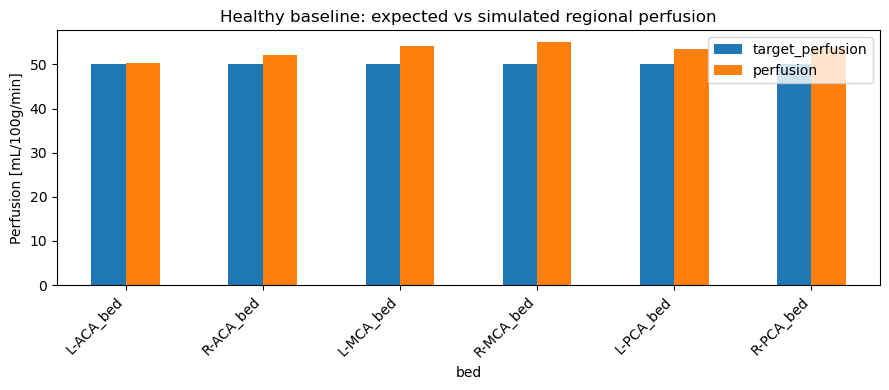

In [7]:
ax = bed_table.plot(
    x="bed",
    y=["target_perfusion", "perfusion"],
    kind="bar",
    figsize=(9, 4),
)
ax.set_ylabel("Perfusion [mL/100g/min]")
ax.set_title("Healthy baseline: expected vs simulated regional perfusion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## CoW flow diagnostic

For a healthy symmetric baseline, the communicating arteries should not dominate the solution. Mean ACom/PCom flows should be small compared with the main inlet/outlet flows.

Sign convention reminder:

- `ACA` positive flow follows the coordinate direction in the JSON geometry. In this config it is useful mainly as a magnitude/collateral-activation metric.
- PCom sign depends on coordinate orientation; again, magnitude and changes between cases are the most useful first diagnostics.


In [8]:
probe_table = summarize_probe_flows(results)
probe_table

,vessel,mean_flow_ml_min
0,BAS,5.877200
1,L-ICA_I,-361.252222
2,R-ICA_I,-438.164040
3,ACA,-39.891805
4,L-PCommA,-93.152308
5,R-PCommA,-83.755477
6,L-MCA,206.411085
7,R-MCA,209.125854
8,L-ACA_II,100.604057
9,R-ACA_II,104.337757


## Discussion

If this baseline does not land near the target range, do not tune the CoW geometry immediately. First check:

1. Are the capillary beds attached to the six distal outflows only?
2. Are `P0` and `P_ven` nonzero in the capillary beds?
3. Is `defaults.p0` close to the pressure inlet mean?
4. Are the pressure inlets too high/low relative to the terminal resistances?

This baseline is the reference case for the stenosis and anatomical-variant experiments.
